# Data Sources and Quality

## TL;DR

The executed tables below read the stored G0-G2 audits directly. They report observed universe and
valuation coverage together with a code-derived configuration-lineage gate. The gate is `pending`
when stored stage fingerprints differ and becomes `pass` only when a unified build produces matching
fingerprints. No artifact rebuild is performed here.

## Context & Methods

This notebook is a compact, public data-quality record for the daily convertible-bond research
pipeline. It reads only existing G0-G2 audit artifacts. Raw market data, credentials, private data
locations, and machine-specific configuration locations are neither opened nor displayed.

### Key Assumptions

- Prices are CNY per bond with face value CNY 100.
- Convertible-bond volume is reported in lots of 10 bonds; reported amount is in CNY 10,000.
- A-share amount is in CNY 1,000.
- Rating, remaining-principal, and conversion-price events become usable on the next market trading
  day after disclosure.
- Signal information is frozen at signal-day close; planned execution is the next trading-day open.


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "artifacts").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from within the repository checkout.")


PROJECT_ROOT = find_project_root()
ARTIFACTS = PROJECT_ROOT / "artifacts"
ASSETS = PROJECT_ROOT / "docs" / "assets"
ASSETS.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from cb_quant.notebook_quality import build_g1_headline, build_lineage_gate

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titleweight": "semibold",
    "axes.labelsize": 10,
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "savefig.bbox": "tight",
})


### Load Sanitized Audit Fields


In [2]:
def read_json(relative_path: str) -> dict:
    return json.loads((ARTIFACTS / relative_path).read_text(encoding="utf-8"))


g0_audit = read_json("G0/research_config_validation_v1.json")
g1_audit = read_json("G1/universe_audit_v1.json")
g2_audit = read_json("G2/valuation_factor_audit_v1.json")

public_g0_fields = pd.DataFrame(
    {
        "Field": ["Schema version", "Research identifier", "Validation status", "Pending decisions"],
        "Observed value": [
            g0_audit["schema_version"],
            g0_audit["research_id"],
            g0_audit["status"],
            g0_audit["pending_decision_count"],
        ],
    }
)
display(public_g0_fields)


,Field,Observed value
0,Schema version,1.0
1,Research identifier,cb_daily_multifactor_v1
2,Validation status,pass
3,Pending decisions,6


## Data Quality Gate

The source contract below is expressed in generic categories and units so the notebook remains
portable. Point-in-time event boundaries are enforced before securities enter the investable panel.


In [3]:
source_contract = pd.DataFrame(
    [
        ["Convertible-bond market", "Daily OHLC, volume, amount", "Price: CNY; volume: lots of 10; amount: CNY 10,000", "Signal-date observation"],
        ["Bond terms and events", "Listing, balance, rating, conversion price", "Balance: CNY; prices: CNY", "Next trading day after disclosure"],
        ["Underlying equity", "Daily OHLC and adjustment factor", "Price: CNY; amount: CNY 1,000", "Same signal date"],
        ["Industry membership", "Daily level-1 constituent snapshot", "Categorical", "As-of signal date"],
    ],
    columns=["Source category", "Required content", "Key units", "Information boundary"],
)
display(source_contract)


,Source category,Required content,Key units,Information boundary
0,Convertible-bond market,"Daily OHLC, volume, amount",Price: CNY; volume: lots of 10; amount: CNY 10...,Signal-date observation
1,Bond terms and events,"Listing, balance, rating, conversion price",Balance: CNY; prices: CNY,Next trading day after disclosure
2,Underlying equity,Daily OHLC and adjustment factor,"Price: CNY; amount: CNY 1,000",Same signal date
3,Industry membership,Daily level-1 constituent snapshot,Categorical,As-of signal date


In [4]:
lineage_gate = build_lineage_gate(
    {"G0": g0_audit, "G1": g1_audit, "G2": g2_audit}
)
lineage_table = pd.DataFrame(
    [
        [
            "Stored stage configuration fingerprints",
            lineage_gate["status"],
            lineage_gate["detail"],
        ]
    ],
    columns=["Lineage check", "Status", "Observed result"],
)
quality_gate = pd.DataFrame(
    [
        ["G0 definition validation", g0_audit["status"], len(g0_audit["errors"])],
        ["G1 universe audit", g1_audit["status"], g1_audit["eligibility_formula_mismatches"]],
        ["G1 event timing", "pass" if g1_audit["event_boundary_check_failures"] == 0 else "fail", g1_audit["event_boundary_check_failures"]],
        ["G2 valuation audit", g2_audit["status"], g2_audit["conversion_value_formula_mismatches"] + g2_audit["conversion_premium_formula_mismatches"] + g2_audit["double_low_formula_mismatches"]],
    ],
    columns=["Gate", "Status", "Observed failures"],
)
display(lineage_table)
display(quality_gate)

,Lineage check,Status,Observed result
0,Stored stage configuration fingerprints,pass,Stored stage configuration fingerprints match.


,Gate,Status,Observed failures
0,G0 definition validation,pass,0
1,G1 universe audit,pass,0
2,G1 event timing,pass,0
3,G2 valuation audit,pass,0


The stored fingerprints are compared without displaying their values. A `pending` result denotes the
known administratively reconciled metadata difference and states that the unified final build is
still pending. After a unified rebuild, matching stored fingerprints will make this gate report
`pass` automatically.

## Results


In [5]:
g1_counts = pd.read_parquet(
    ARTIFACTS / "G1/universe_counts_by_signal_date_v1.parquet"
)
coverage_table = pd.DataFrame(
    [
        ["G1 rating coverage", g1_counts["eligible_rating_coverage"].mean()],
        ["G1 mean industry coverage", g1_counts["eligible_industry_coverage"].mean()],
        ["G2 absolute valuation coverage", g2_audit["valuation_coverage"]],
        ["G2 same-parity relative coverage", g2_audit["relative_value_coverage"]],
    ],
    columns=["Metric", "Coverage"],
)
coverage_table["Coverage (%)"] = coverage_table["Coverage"] * 100

date_coverage = build_g1_headline(g1_audit)
display(date_coverage)
display(coverage_table[["Metric", "Coverage (%)"]].round(2))


,Metric,Observed value
0,Signal dates,222
1,Candidate observations,208680
2,Investable observations,44728
3,Distinct investable bonds,846


,Metric,Coverage (%)
0,G1 rating coverage,100.00
1,G1 mean industry coverage,99.06
2,G2 absolute valuation coverage,100.00
3,G2 same-parity relative coverage,99.12


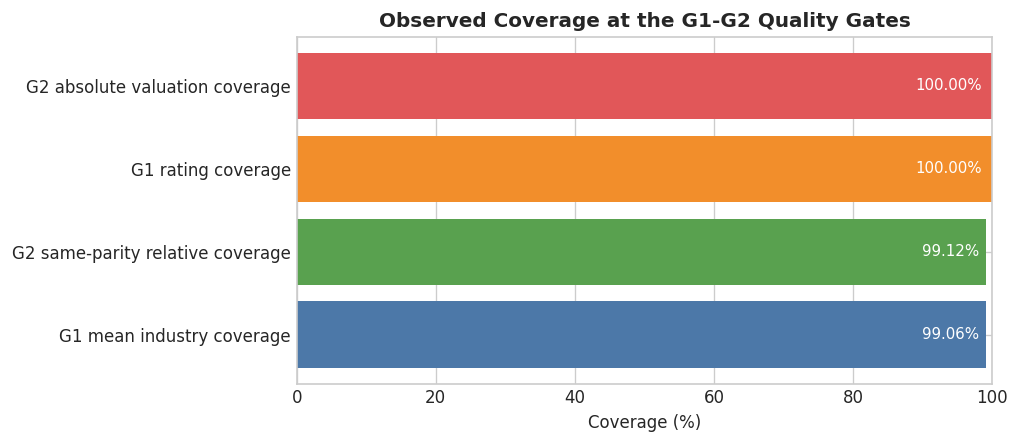

In [6]:
fig, ax = plt.subplots(figsize=(8.6, 3.8))
plot_data = coverage_table.sort_values("Coverage (%)")
ax.barh(plot_data["Metric"], plot_data["Coverage (%)"], color=["#4C78A8", "#59A14F", "#F28E2B", "#E15759"])
ax.set_xlim(0, 100)
ax.set_xlabel("Coverage (%)")
ax.set_title("Observed Coverage at the G1-G2 Quality Gates")
for index, value in enumerate(plot_data["Coverage (%)"]):
    ax.text(min(value - 1.0, 98.5), index, f"{value:.2f}%", ha="right", va="center", color="white", fontsize=9)
fig.tight_layout()
fig.savefig(ASSETS / "g0_data_quality_coverage.png")
plt.show()


## Takeaways

- Formula and event-boundary checks report zero observed failures in the stored audits.
- The executed coverage tables are derived from stored audit fields rather than copied constants.
- The lineage gate reports the actual stored-fingerprint state and does not expose fingerprint values
  or machine-specific paths.
- No future-return label or predictive-performance claim is used in this notebook.